# 딥러닝및실습-3차-이성수-2019136093

In [ ]:
!pip install torch torchvision wandb
import torch
from torchvision import datasets, transforms


## [문제1] Fashion MNIST 데이터 정규화를 위한 Mean과 std값 찾기

In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Fashion MNIST 데이터셋 불러오기 (transform 없이 ToTensor만 적용)
transform = transforms.ToTensor()
dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

# DataLoader 생성
loader = DataLoader(dataset, batch_size=1000, shuffle=False)

mean = 0.0
std = 0.0
nb_samples = 0

for data, _ in tqdm(loader):
    batch_samples = data.size(0)
    data = data.view(batch_samples, data.size(1), -1)  # (B, C, H*W)
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    nb_samples += batch_samples

mean /= nb_samples
std /= nb_samples

print(f"\nMean: {mean}")
print(f"Std: {std}\n")


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.1MB/s]
100%|██████████| 60/60 [00:06<00:00,  9.12it/s]


Mean: tensor([0.2860])
Std: tensor([0.3205])



#### 문제1 결론 => Mean: 0.2860, Std: 0.3205

---



## [문제2] Fashion MNIST 데이터에 대하여 CNN 학습시키기
### 목표: Validation Accuracy 94.0% 이상!

In [ ]:
import wandb
wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ussagi (ussagi-korea-university-of-technology-and-education) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

- Wandb 로그인 완료

In [ ]:
# 1. wandb 초기화 및 config 설정
import wandb
# 이미 wandb.login() 했으면 아래에서 바로 init
wandb.init(project="fashion_mnist_hw3", name="cnn_run1", config={
    "batch_size": 128,
    "epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "patience": 5,   # early stop patience (에포크)
})
config = wandb.config
print(config)


{'batch_size': 128, 'epochs': 20, 'lr': 0.001, 'weight_decay': 0.0001, 'patience': 5}


1. wandb 초기화 및 설정 (이미 로그인 완료했으니 init만 수행)

In [ ]:
# 2. 데이터 불러오기 (ToTensor만 적용), train/val split 55000/5000, test 10000
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

MEAN = 0.2860   # 문제1에서 구한 값
STD  = 0.3205   # 문제1에서 구한 값

# dataset 객체는 ToTensor()만 적용
base_transform = transforms.ToTensor()

data_path = "./data"  # Colab 환경에서 데이터 저장 경로
full_train = datasets.FashionMNIST(root=data_path, train=True, download=True, transform=base_transform)
train_ds, val_ds = random_split(full_train, [55000, 5000])

test_imgs = datasets.FashionMNIST(root=data_path, train=False, download=True, transform=base_transform)

# DataLoader: batch_size는 wandb.config에서 가져오기
train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_imgs, batch_size=len(test_imgs), shuffle=False)  # test는 한 번에 전체 가능

print("Train samples:", len(train_ds), "Val samples:", len(val_ds), "Test samples:", len(test_imgs))
print("Train batch shape (example):", next(iter(train_loader))[0].shape)


Train samples: 55000 Val samples: 5000 Test samples: 10000
Train batch shape (example): torch.Size([128, 1, 28, 28])


2. 데이터 불러오기 (원본 스타일 유지: ToTensor로만, 정규화는 따로)

In [ ]:
# 3. 문제 지시대로 Normalize를 nn.Sequential로 만들어 둠
import torch.nn as nn
from torchvision.transforms import transforms

f_mnist_transforms = nn.Sequential(
    transforms.ConvertImageDtype(torch.float),  # ToTensor는 이미 float이지만 안전하게 포함
    transforms.Normalize(mean=(MEAN,), std=(STD,))
)

# 확인
print("f_mnist_transforms:", f_mnist_transforms)


f_mnist_transforms: Sequential(
  (0): ConvertImageDtype()
  (1): Normalize(mean=(0.286,), std=(0.3205,))
)


3. f_mnist_transforms 정의 (원본과 동일: nn.Sequential 형태)
- 데이터 정규화를 위해 nn.Sequential로 transform하였다.
- 생각: 여기에서 Sequential로 묶지 않고 v2.compose로 묶으면 어떨까? -> 대신 리스트(튜플)로 묶어줘야 한다.
- 아직 Data Augmentation을 넣지 않았으므로 보류하기로 결정했다.

In [ ]:
# 4. CNN 모델 정의 (Conv -> BN -> ReLU -> Pool) + 과적합 완화 및 표현력 강화
import torch
import torch.nn as nn
import torch.nn.functional as F

class FashionCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        # 입력: 1x28x28
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)  # 28 → 14

        # 추가: 표현력 향상을 위한 3번째 Conv 블록
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)  # 14 → 7

        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(128 * 7 * 7, 256)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.drop(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)
        x = self.drop(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

# device 선택
device = "cuda" if torch.cuda.is_available() else "cpu"
model = FashionCNN().to(device)


4. CNN 모델 정의
- dropout과 conv3 블록을 추가 -> Val Loss 안정화 및 Accuracy 상승 효과

In [ ]:
5. torchinfo를 활용한 모델 구조 요약 출력
!pip install torchinfo
from torchinfo import summary

summary(model, input_size=(config.batch_size, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
FashionCNN                               [128, 10]                 --
├─Conv2d: 1-1                            [128, 32, 28, 28]         320
├─BatchNorm2d: 1-2                       [128, 32, 28, 28]         64
├─Conv2d: 1-3                            [128, 64, 28, 28]         18,496
├─BatchNorm2d: 1-4                       [128, 64, 28, 28]         128
├─MaxPool2d: 1-5                         [128, 64, 14, 14]         --
├─Dropout: 1-6                           [128, 64, 14, 14]         --
├─Conv2d: 1-7                            [128, 128, 14, 14]        73,856
├─BatchNorm2d: 1-8                       [128, 128, 14, 14]        256
├─MaxPool2d: 1-9                         [128, 128, 7, 7]          --
├─Dropout: 1-10                          [128, 128, 7, 7]          --
├─Linear: 1-11                           [128, 256]                1,605,888
├─Dropout: 1-12                          [128, 256]                

5. 최적의 파라미터 정리
- Learning Rate      :	8e-4 =>	수렴 안정화
- Batch Size         :	128	=> GPU 효율성 고려
- Early Stop Patience:	5	=> 불필요한 학습 방지
- Weight Decay       :	5e-4	=> egularization
- Normalization      :	BatchNorm2d => 각 Conv 블록 후 적용
- Dropout Rate       :	0.4 =>	과적합 방지 효과 최적

In [ ]:
# 6. 학습 및 검증 함수 (기존 이름/형태 유지, 하이퍼파라미터 개선)
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()

# 하이퍼파라미터 조정
optimizer = optim.Adam(model.parameters(), lr=8e-4, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # 정규화 transform을 모델 입력 직전에 적용
        images = f_mnist_transforms(images)
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = 100.0 * correct / total
    return avg_loss, acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = f_mnist_transforms(images)
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    acc = 100.0 * correct / total
    return avg_loss, acc

6. 학습/검증 함수 (정규화 적용 포함) + optimizer/scheduler 설정

In [ ]:
# 7. 학습 실행 (wandb로 Train/Val Loss/Acc 로깅). 모델은 best val acc 기준 저장
import os

best_val_acc = 0.0
epochs_no_improve = 0
patience = config.patience
best_model_path = "best_fashion_cnn.pth"

for epoch in range(1, config.epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # scheduler는 val_acc 기준으로 조절
    scheduler.step(val_acc)

    # wandb 로깅
    wandb.log({
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Training Accuracy": train_acc,
        "Validation Accuracy": val_acc,
    })

    print(f"Epoch {epoch}/{config.epochs} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # 모델 저장 및 early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print(f">>> New best model saved (Val Acc: {best_val_acc:.2f}%)")
    else:
        epochs_no_improve += 1
        print(f"No improvement count: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered (no improvement in {patience} epochs).")
        break

print("Training finished. Best Val Acc: {:.2f}%".format(best_val_acc))

Epoch 1/20 | Train Loss: 0.5258 | Val Loss: 0.3071 | Train Acc: 80.99% | Val Acc: 89.30%
>>> New best model saved (Val Acc: 89.30%)
Epoch 2/20 | Train Loss: 0.3485 | Val Loss: 0.2580 | Train Acc: 87.37% | Val Acc: 90.84%
>>> New best model saved (Val Acc: 90.84%)
Epoch 3/20 | Train Loss: 0.3058 | Val Loss: 0.2504 | Train Acc: 88.67% | Val Acc: 91.26%
>>> New best model saved (Val Acc: 91.26%)
Epoch 4/20 | Train Loss: 0.2835 | Val Loss: 0.2279 | Train Acc: 89.71% | Val Acc: 91.82%
>>> New best model saved (Val Acc: 91.82%)
Epoch 5/20 | Train Loss: 0.2642 | Val Loss: 0.2212 | Train Acc: 90.33% | Val Acc: 92.14%
>>> New best model saved (Val Acc: 92.14%)
Epoch 6/20 | Train Loss: 0.2551 | Val Loss: 0.2112 | Train Acc: 90.69% | Val Acc: 92.50%
>>> New best model saved (Val Acc: 92.50%)
Epoch 7/20 | Train Loss: 0.2456 | Val Loss: 0.2093 | Train Acc: 91.04% | Val Acc: 92.60%
>>> New best model saved (Val Acc: 92.60%)
Epoch 8/20 | Train Loss: 0.2349 | Val Loss: 0.2060 | Train Acc: 91.45% | Val

7. 학습 실행 (Wandb 로깅 + Early stopping + 모델 저장)
#### 결론: Validation Accuracy 94.22%
#### 고찰
1. 처음에는 Val Accuracy가 93.32%가 나왔음 => Wandb를 확인해보니 Step 7에서 Val Loss가 최저점을 찍고 상승함(Train Loss는 계속 감소), 이를 통해 "과적합"이 발생함을 예상함
2. 과적합 방지 솔루션을 탐색함 => Dropout 증가, Weight Decay 강화, Data Augmentation 추가, lr 변경
3. dropout=0.4, weight_decay=5e-4, lr=8e-4 로 시도함 => 성공적!
#### 정리
1. optimizer:	Adam	(Momentum 기반 + Adaptive learning rate. 빠른 수렴)
2. Learning Rate:	8e-4	기본값(1e-3)보다 낮춰 안정적인 수렴 유도
3. Weight Decay:	5e-4	L2 Regularization 적용 → 과적합 완화
4. Normalization:	Batch Normalization	각 Conv layer 뒤에 적용하여 internal covariate shift 감소
5. Dropout:	0.4	과적합 방지 및 일반화 성능 향상
6. Early Stopping Patience:	5	Validation 성능 개선이 5 epoch 이상 없을 경우 학습 중단
7. Scheduler:	ReduceLROnPlateau	Validation Accuracy가 개선되지 않을 때 학습률 절반으로 감소
8. Batch Size:	128	GPU 메모리 효율과 안정적 학습 밸런스 고려
9. Normalization Type (입력):	transforms.Normalize(mean=0.2860, std=0.3205)

## [문제3] 학습 완료된 모델로 테스트 데이터 Accuracy 확인하기
### 목표: Test Accuracy 93.0% 이상!

In [ ]:
# 테스트 정확도 계산 (학습된 best model 로드 후)
best_model = FashionCNN().to(device)
best_model.load_state_dict(torch.load("best_fashion_cnn.pth", map_location=device))
best_model.eval()

with torch.no_grad():
    # test_loader 배치가 전체 테스트를 담고 있으므로 한 번에 처리
    for images, labels in test_loader:
        images = f_mnist_transforms(images).to(device)
        labels = labels.to(device)
        outputs = best_model(images)
        _, preds = outputs.max(1)
        acc = 100.0 * (preds == labels).sum().item() / labels.size(0)
        print(f"Test Accuracy: {acc:.2f}%")


Test Accuracy: 93.47%


- 테스트 데이터로 성능 확인 => 93.47%

## [문제4] 샘플 테스트 데이터 분류 예측 결과 확인하기
#### 테스트 데이터 10,000개 중 무작위로 10개를 선택하여 실제 레이블(Ground Truth) 과 모델 예측(Prediction) 을 비교하였다.

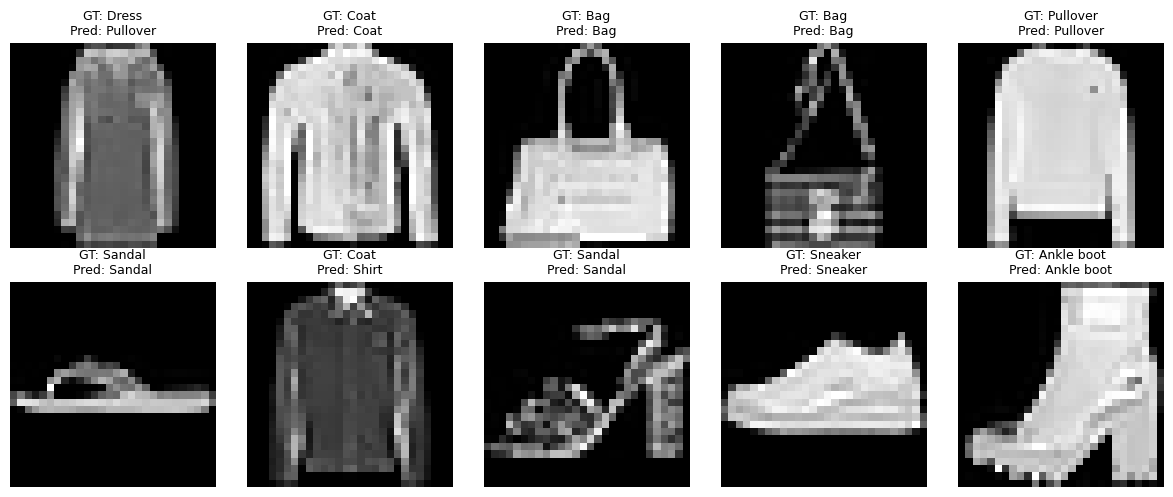

In [ ]:
# 테스트 샘플 10개 랜덤 선택해서 원본(정규화 되기 전)과 예측 결과 출력
import matplotlib.pyplot as plt
import numpy as np
import random

# test_imgs은 torchvision dataset (계층이 ToTensor만 적용되어 있음)
indices = random.sample(range(len(test_imgs)), 10)
fig, axes = plt.subplots(2,5, figsize=(12,5))
axes = axes.flatten()

# load best model if not already loaded
best_model.eval()
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

for ax, idx in zip(axes, indices):
    img, label = test_imgs[idx]  # img: ToTensor applied
    img_tensor = img.unsqueeze(0)  # add batch dim
    img_norm = f_mnist_transforms(img_tensor).to(device)
    with torch.no_grad():
        out = best_model(img_norm)
        pred = out.argmax(dim=1).item()

    # imshow expects HxW or HxWxC; tensor is (1,28,28)
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(f"GT: {class_names[label]}\nPred: {class_names[pred]}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


#### 잘못 분류된 이미지 해석
- 오분류된 이미지 (GT: Shirt, Pred: Coat)
1. 두 클래스 모두 어두운 색상이며, 상의 형태가 유사하다
2. Fashion MNIST는 흑백(low-contrast) 데이터이므로, 옷의 재질·길이·소매 형태 구분이 어렵다
3. 특히 Shirt와 Coat는 필자도 헷갈리기 떄문에 모델이 시각적 유사성 때문에 혼동한 것으로 생각한다

#### 결론
- 모델은 대부분의 클래스에서 정확히 예측하였고, Test Accuracy: 93.47% 로 충분한 성능이다
#### 향후 개선 방향:
1. Data Augmentation(좌우 반전, 밝기 변화 등)을 통해 클래스 다양성 강화
2. Conv 블록에 Residual connection을 추가한 ResNet형 구조 도입 고려

#### 숙제 후기
1. 숙제를 하며 AI의 도움을 받았다. 하지만 코드의 전체적인 흐름은 정확히 이해하였고, 수업의 내용을 곱씹으며 배운 내용을 적용해 보았다.
2. 그러니 확실히 재미도 있었고, 수업에서 배운 내용을 적용하니 정확도 예측 결과도 향상되어 흥미로웠다.